# Week 12 - Kernel Methods

Learning contents:
* Kernel Regression
    * Compute Gram Matrix
    * Estimate the target values for a new set of data points
    * Plot the (x_new, t_new)-pairs on top of the original data
    * Play around with the kernel $\sigma$. How does the fit look using $\sigma=1$ as compared to  $\sigma=10$?


In [1]:
# Dependencies
import numpy as np
import pandas as pd
import scipy
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set();

# 1) Kernel Regression

We'll be working with two variable from the [Boston housing dataset](https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html)

In [80]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

x = data[:,12] # LSTAT: % lower status of the population.
t = target # MEDV: Median value of owner-occupied homes in $1000s.

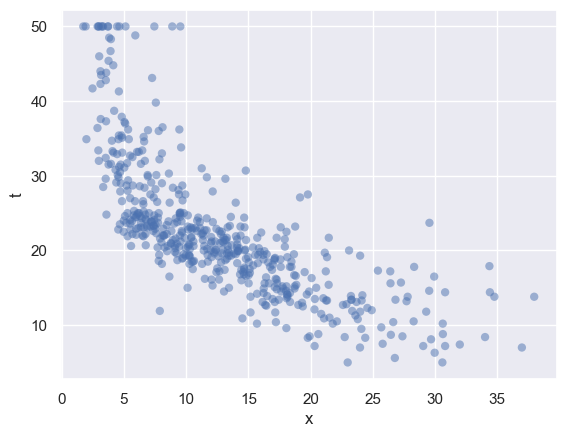

In [3]:
def plot_scatter(data, target, alpha=0.5, legend=True):
    scatter = plt.scatter(data, target,  edgecolor='none', alpha=alpha)
    plt.xlabel('x')
    plt.ylabel('t')

# Let's plot all the data in 2D
plot_scatter(x, t)

## 1.1) Compute the kernel gram matrix
Do it using the Gaussian Kernel based on Euclidean distance.

Use $\sigma = 2$

First, perform the computation for the 5 first samples. Then do it for all samples. What is the shape of the Gram matrix for all samples?

In [27]:
sigma = 2

In [79]:
# Compute Gram matrix for 5 first samples
def kern_func(x, x_1):
    return np.exp(-np.linalg.norm(x-x_1)**2 / (2 * sigma**2))

def compute_gram_matrix(x, sigma):
    n = len(x)
    gram_matrix = np.zeros((n,n))

    for i in range(n):
        for j in range(n):
            gram_matrix[i,j] = np.exp(-np.linalg.norm(x[i]-x[j])**2 / (2 * sigma**2))
    return gram_matrix

compute_gram_matrix(x[:5], sigma)


array([[1.        , 0.11495667, 0.89331814, 0.59440166, 0.98480414],
       [0.11495667, 1.        , 0.03823467, 0.0081887 , 0.16291731],
       [0.89331814, 0.03823467, 1.        , 0.86198923, 0.80957165],
       [0.59440166, 0.0081887 , 0.86198923, 1.        , 0.48967543],
       [0.98480414, 0.16291731, 0.80957165, 0.48967543, 1.        ]])

In [85]:
# Compute Gram matrix for all samples
K = compute_gram_matrix(x, sigma)
print("shape = {}".format(K.shape))
K

shape = (506, 506)


array([[1.        , 0.11495667, 0.89331814, ..., 0.94700586, 0.7548396 ,
        0.3495006 ],
       [0.11495667, 1.        , 0.03823467, ..., 0.21626517, 0.41294123,
        0.82000077],
       [0.89331814, 0.03823467, 1.        , ..., 0.7232412 , 0.47221896,
        0.15679556],
       ...,
       [0.94700586, 0.21626517, 0.7232412 , ..., 1.        , 0.91557774,
        0.53408515],
       [0.7548396 , 0.41294123, 0.47221896, ..., 0.91557774, 1.        ,
        0.78270454],
       [0.3495006 , 0.82000077, 0.15679556, ..., 0.53408515, 0.78270454,
        1.        ]])

## 1.2) Estimate the target values for a new set of data points
Use a regularisation term of lambda = 0.001

In [91]:
l = 0.001 # lambda
sigma = 2
x_new = np.linspace(0, 40, 100) # Range in which to compute estimated values


In [87]:
def ny_k_mærke(x, x_newer):

    gram_matrix = np.zeros((506,100))
    for i in range(506):
        for j in range(100):
            gram_matrix[i,j] = np.exp(-np.linalg.norm(x[i]-x_newer[j])**2 / (2 * sigma**2))
    print(gram_matrix)
    return gram_matrix

ny_gram = ny_k_mærke(x, x_new)

t_new = ny_gram.T @ np.linalg.inv(K + l * np.eye(506)) @ t
t_new

[[4.50469500e-02 7.29905150e-02 1.13538452e-01 ... 2.88209973e-64
  8.91320419e-66 2.64627034e-67]
 [2.91676599e-05 7.19439109e-05 1.70357791e-04 ... 9.38885887e-50
  4.42006932e-51 1.99765668e-52]
 [1.31320747e-01 1.93312375e-01 2.73187909e-01 ... 7.61954126e-68
  2.14081408e-69 5.77436967e-71]
 ...
 [1.87567798e-02 3.24872001e-02 5.40184089e-02 ... 7.72039542e-62
  2.55221561e-63 8.09973257e-65]
 [5.25381920e-03 9.90554452e-03 1.79290421e-02 ... 8.11580451e-59
  2.92050949e-60 1.00893031e-61]
 [4.25689649e-04 9.24510190e-04 1.92755073e-03 ... 5.95993507e-54
  2.47049486e-55 9.83109479e-57]]


array([70.65814877, 66.54493624, 60.40011825, 53.76864336, 48.11766362,
       44.36783446, 42.61210592, 42.1546034 , 41.87313991, 40.75728657,
       38.37490877, 35.03779999, 31.58224143, 28.88780079, 27.40917481,
       26.98876155, 27.04157118, 26.96574512, 26.49346186, 25.75912341,
       25.07956743, 24.64922381, 24.39283367, 24.06703281, 23.49283897,
       22.70888565, 21.92692019, 21.3521622 , 21.03717816, 20.88461317,
       20.76676725, 20.63218749, 20.50439149, 20.39663867, 20.24666985,
       19.94377407, 19.41995441, 18.71345063, 17.94634178, 17.24629944,
       16.69144849, 16.31937826, 16.16273802, 16.24292589, 16.50684984,
       16.77441046, 16.78378808, 16.34355022, 15.48988202, 14.51139023,
       13.79073358, 13.55864091, 13.73811015, 13.99911123, 13.98788365,
       13.56444332, 12.88033122, 12.25301986, 11.94168953, 11.98790973,
       12.21965368, 12.39117834, 12.34474372, 12.08826885, 11.76145835,
       11.54030564, 11.55137463, 11.8334048 , 12.3377656 , 12.94

## 1.3) Plot the (x_new, t_new)-pairs on top of the original data
Hint: You can use `seaborn.lineplot`

<Axes: xlabel='x', ylabel='t'>

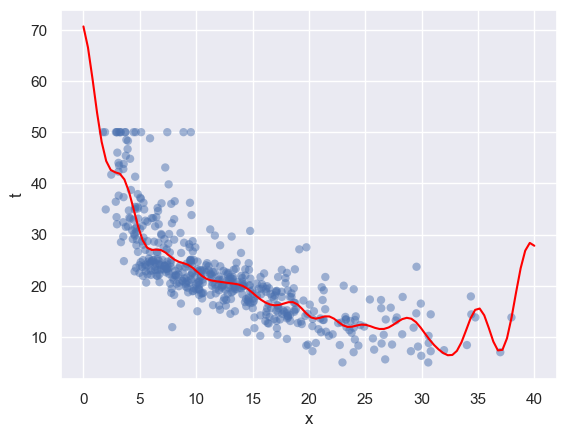

In [89]:
plot_scatter(x,t)
sns.lineplot(x = x_new, y= t_new, color= "red")


## 1.4) Play around with the kernel $\sigma$. How does the fit look using $\sigma=1$ as compared to  $\sigma=10$?

[[4.11776507e-006 2.83834845e-005 1.66177366e-004 ... 6.89979235e-255
  6.31154122e-261 4.90384617e-267]
 [7.23779619e-019 2.67902132e-017 8.42263545e-016 ... 7.77054078e-197
  3.81694868e-202 1.59251456e-207]
 [2.97394803e-004 1.39649257e-003 5.56988072e-003 ... 3.37066275e-269
  2.10046675e-275 1.11177866e-281]
 ...
 [1.23775054e-007 1.11390751e-006 8.51465690e-006 ... 3.55269707e-245
  4.24296493e-251 4.30410363e-257]
 [7.61904421e-010 9.62749754e-009 1.03330457e-007 ... 4.33836721e-233
  7.27502497e-239 1.03620261e-244]
 [3.28376721e-014 7.30544725e-013 1.38045823e-011 ... 1.26172908e-213
  3.72508183e-219 9.34130462e-225]]
[[4.11776507e-006 2.83834845e-005 1.66177366e-004 ... 6.89979235e-255
  6.31154122e-261 4.90384617e-267]
 [7.23779619e-019 2.67902132e-017 8.42263545e-016 ... 7.77054078e-197
  3.81694868e-202 1.59251456e-207]
 [2.97394803e-004 1.39649257e-003 5.56988072e-003 ... 3.37066275e-269
  2.10046675e-275 1.11177866e-281]
 ...
 [1.23775054e-007 1.11390751e-006 8.51465690

<Axes: xlabel='x', ylabel='t'>

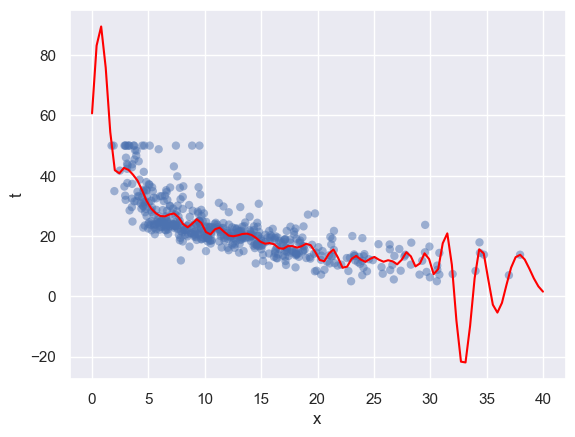

In [96]:
sigma = 1
K = compute_gram_matrix(x, sigma)
ny_k_mærke(x, x_newer=x_new)

ny_gram = ny_k_mærke(x, x_new)

t_new = ny_gram.T @ np.linalg.inv(K + l * np.eye(506)) @ t

plot_scatter(x,t)
sns.lineplot(x = x_new, y= t_new, color= "red")


[[0.88337807 0.90059733 0.91665459 ... 0.00287335 0.00250035 0.00217223]
 [0.65856108 0.68277838 0.70673155 ... 0.01093716 0.0096787  0.00855108]
 [0.92200512 0.93637624 0.94942018 ... 0.0020667  0.00179153 0.00155046]
 ...
 [0.85295542 0.87190364 0.88981899 ... 0.0035934  0.00313528 0.00273111]
 [0.81062315 0.83144808 0.85141693 ... 0.0047465  0.00415545 0.00363207]
 [0.73310085 0.75619964 0.7787539  ... 0.00743036 0.00654201 0.00575048]]
[[0.88337807 0.90059733 0.91665459 ... 0.00287335 0.00250035 0.00217223]
 [0.65856108 0.68277838 0.70673155 ... 0.01093716 0.0096787  0.00855108]
 [0.92200512 0.93637624 0.94942018 ... 0.0020667  0.00179153 0.00155046]
 ...
 [0.85295542 0.87190364 0.88981899 ... 0.0035934  0.00313528 0.00273111]
 [0.81062315 0.83144808 0.85141693 ... 0.0047465  0.00415545 0.00363207]
 [0.73310085 0.75619964 0.7787539  ... 0.00743036 0.00654201 0.00575048]]


<Axes: xlabel='x', ylabel='t'>

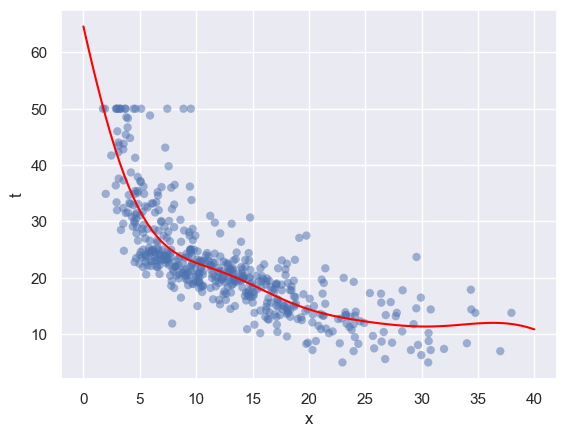

In [97]:
sigma = 10
K = compute_gram_matrix(x, sigma)
ny_k_mærke(x, x_newer=x_new)

ny_gram = ny_k_mærke(x, x_new)

t_new = ny_gram.T @ np.linalg.inv(K + l * np.eye(506)) @ t

plot_scatter(x,t)
sns.lineplot(x = x_new, y= t_new, color= "red")

